In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import proplot as pplt

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

In [2]:
expnames=['T63L26_CNTRL','T63L26_IOPAC','T63L26_HeatingSA','T63L26_HeatingALL']
basepath='/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/'
DataSetname = ['uvel','vvel','geo']
Dataname = ['u','v','geo']

In [3]:
ds_exps_list=[]
for e in expnames:
    datapath=basepath+e+'/'
    ds_list=[]
    for dsn,dn in zip(DataSetname,Dataname):
        fnames=datapath+dsn+'_Pressure_*.nc'
        print(fnames)
        ds=xr.open_mfdataset(fnames,combine='by_coords')
        ds_list.append(ds)
    ds_all=xr.merge(ds_list)  
    ds_exps_list.append(ds_all)
ds_exps=xr.combine_nested(ds_exps_list,concat_dim='exp')
ds_exps['exp']=expnames

/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_CNTRL/uvel_Pressure_*.nc


/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_CNTRL/vvel_Pressure_*.nc
/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_CNTRL/geo_Pressure_*.nc
/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_IOPAC/uvel_Pressure_*.nc
/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_IOPAC/vvel_Pressure_*.nc
/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_IOPAC/geo_Pressure_*.nc
/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_HeatingSA/uvel_Pressure_*.nc
/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_HeatingSA/vvel_Pressure_*.nc
/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_HeatingSA/geo_Pressure_*.nc
/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_HeatingALL/uvel_Pressure_*.nc
/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_HeatingALL/vvel_Pressure_*.nc
/home/kpegion/projects/Atmospheric-Teleconnection-M

In [4]:
fnames

'/home/kpegion/projects/Atmospheric-Teleconnection-Model-main/T63L26_HeatingALL/geo_Pressure_*.nc'

In [5]:
ds_exps

<xarray.Dataset>
Dimensions:  (exp: 4, time: 720, lev: 4, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 1950-01-01 1950-01-02 ... 1951-12-21
  * lev      (lev) float64 850.0 500.0 300.0 200.0
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * exp      (exp) <U17 'T63L26_CNTRL' 'T63L26_IOPAC' ... 'T63L26_HeatingALL'
Data variables:
    u        (exp, time, lev, lat, lon) float64 dask.array<chunksize=(1, 720, 4, 96, 192), meta=np.ndarray>
    v        (exp, time, lev, lat, lon) float64 dask.array<chunksize=(1, 720, 4, 96, 192), meta=np.ndarray>
    geo      (exp, time, lev, lat, lon) float64 dask.array<chunksize=(1, 720, 4, 96, 192), meta=np.ndarray>

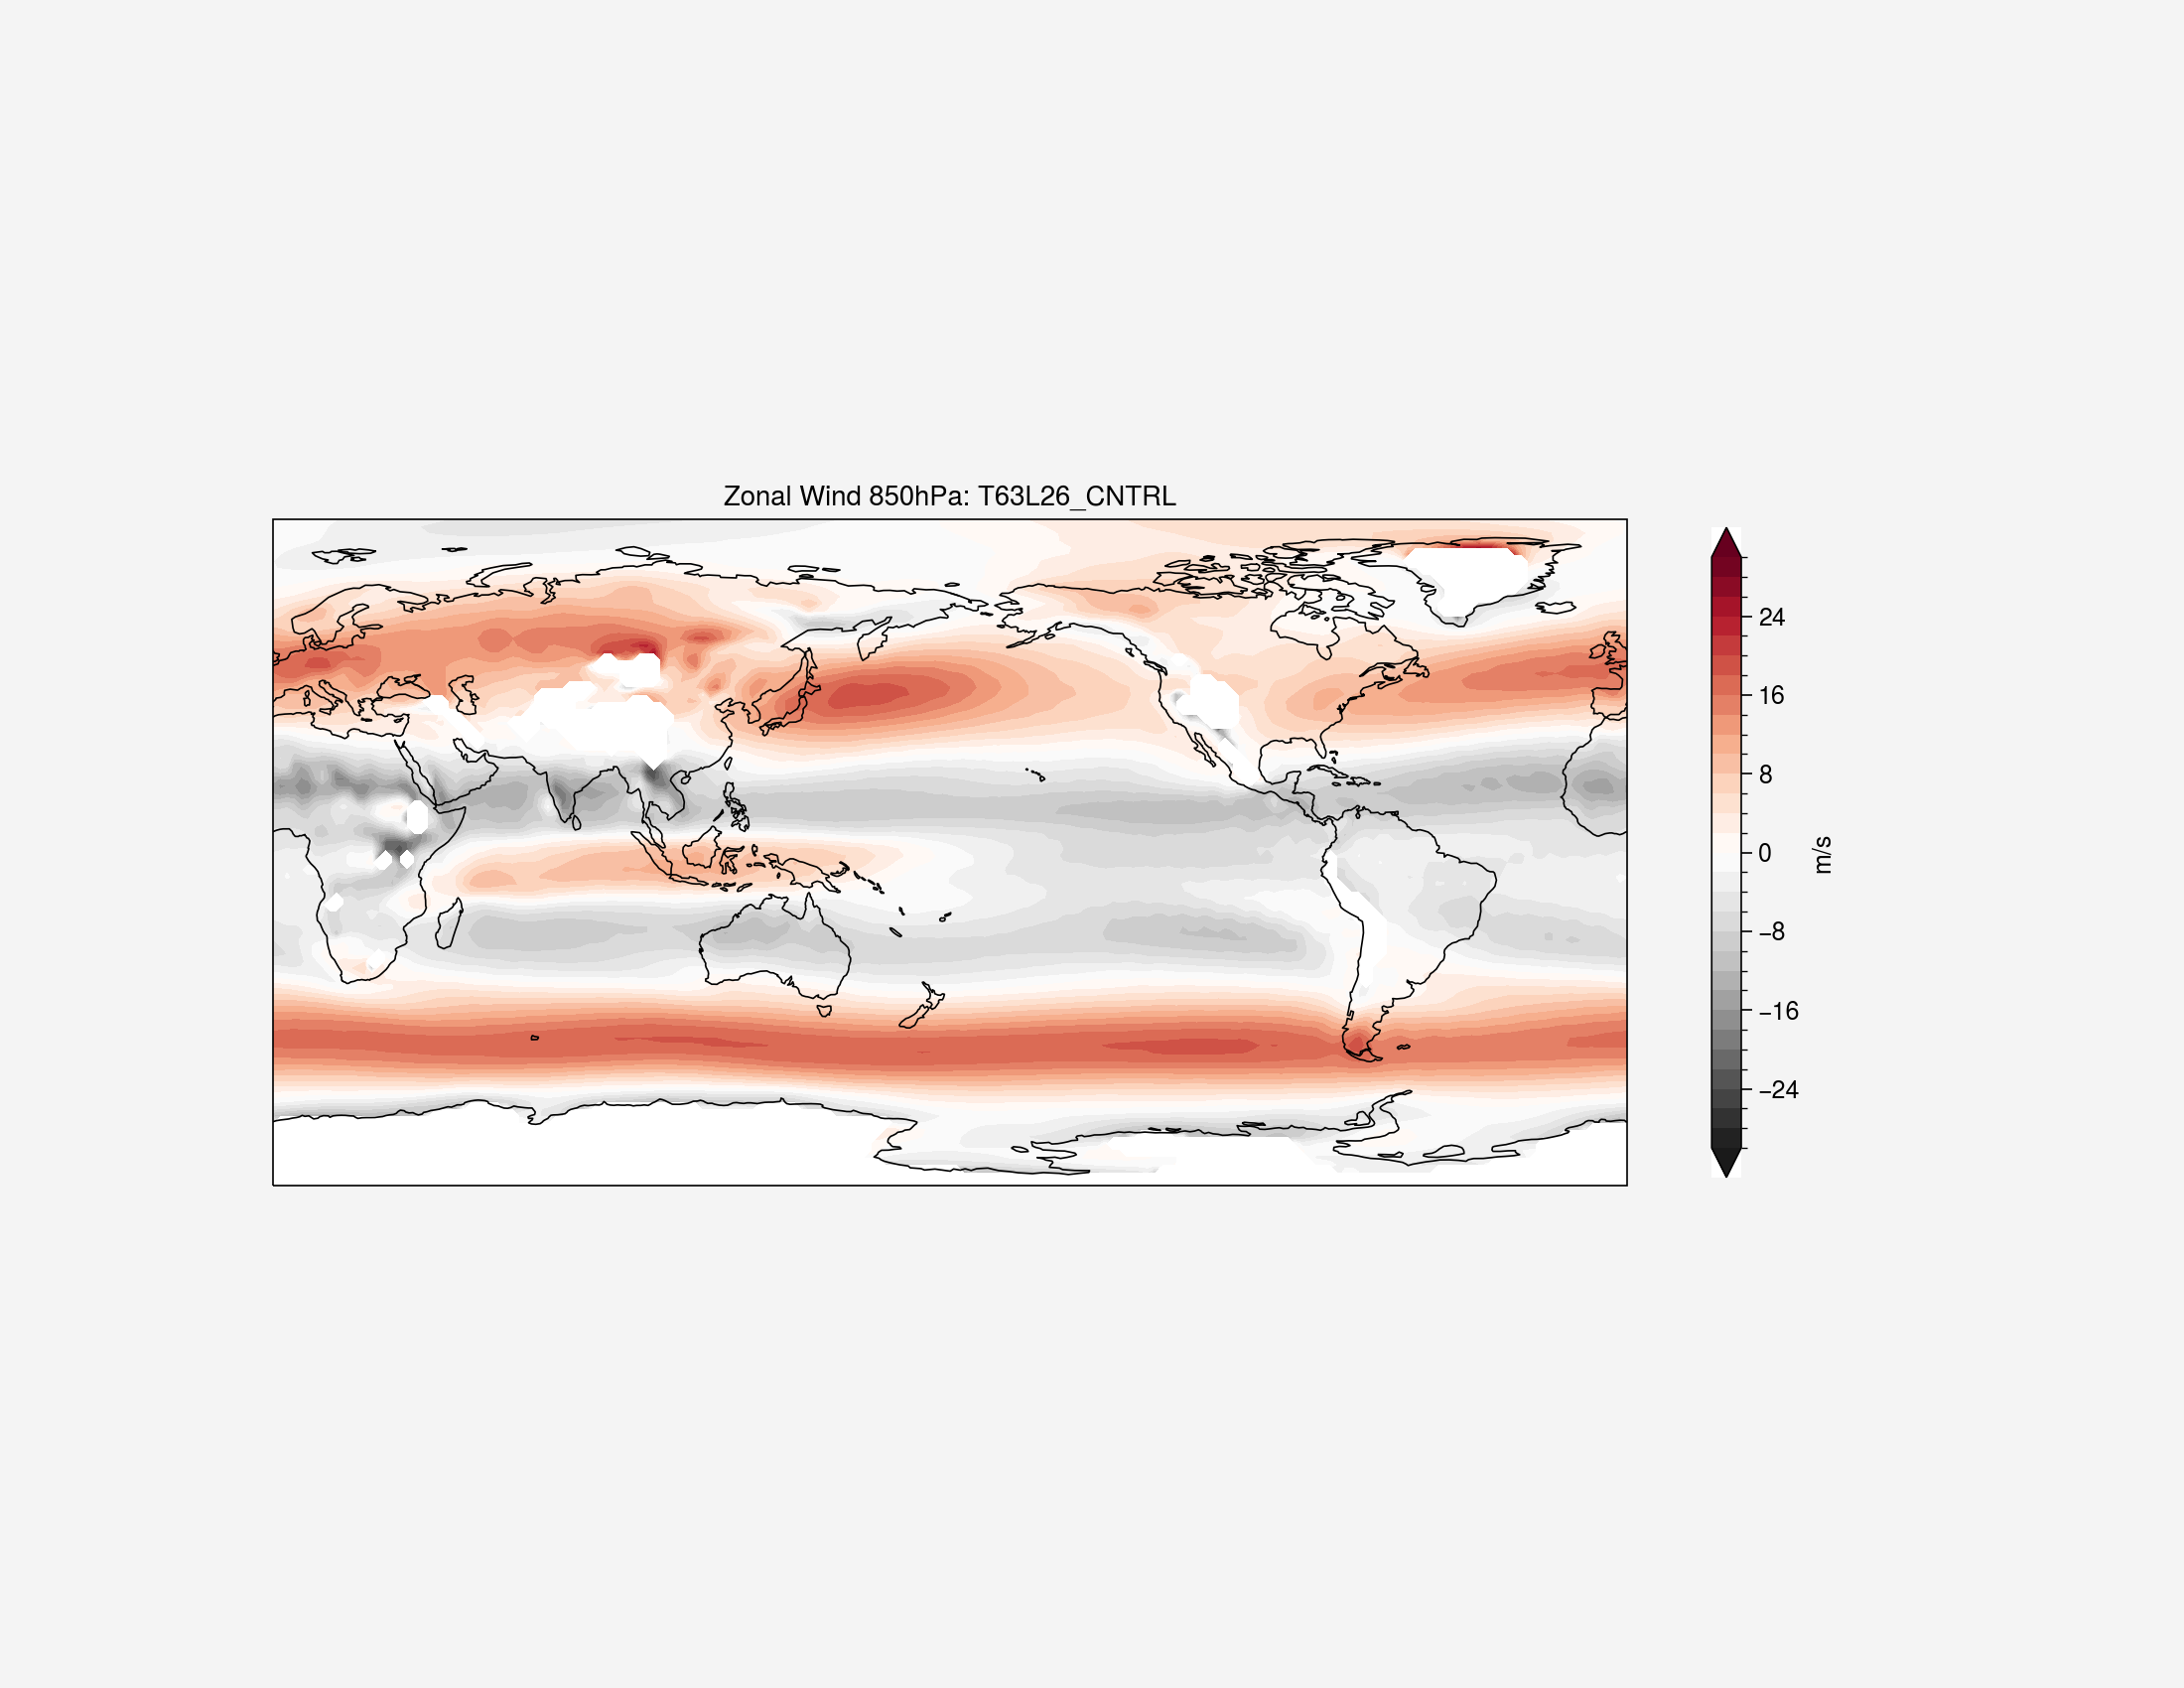

In [6]:
exp='T63L26_CNTRL'
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=ds_exps['u'].sel(lev=850.0,exp=exp).mean(dim='time')
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both',levels=np.arange(-30,31,2))
ax.coastlines()
plt.title('Zonal Wind 850hPa: '+exp)
plt.colorbar(cs,shrink=0.5,label='m/s')

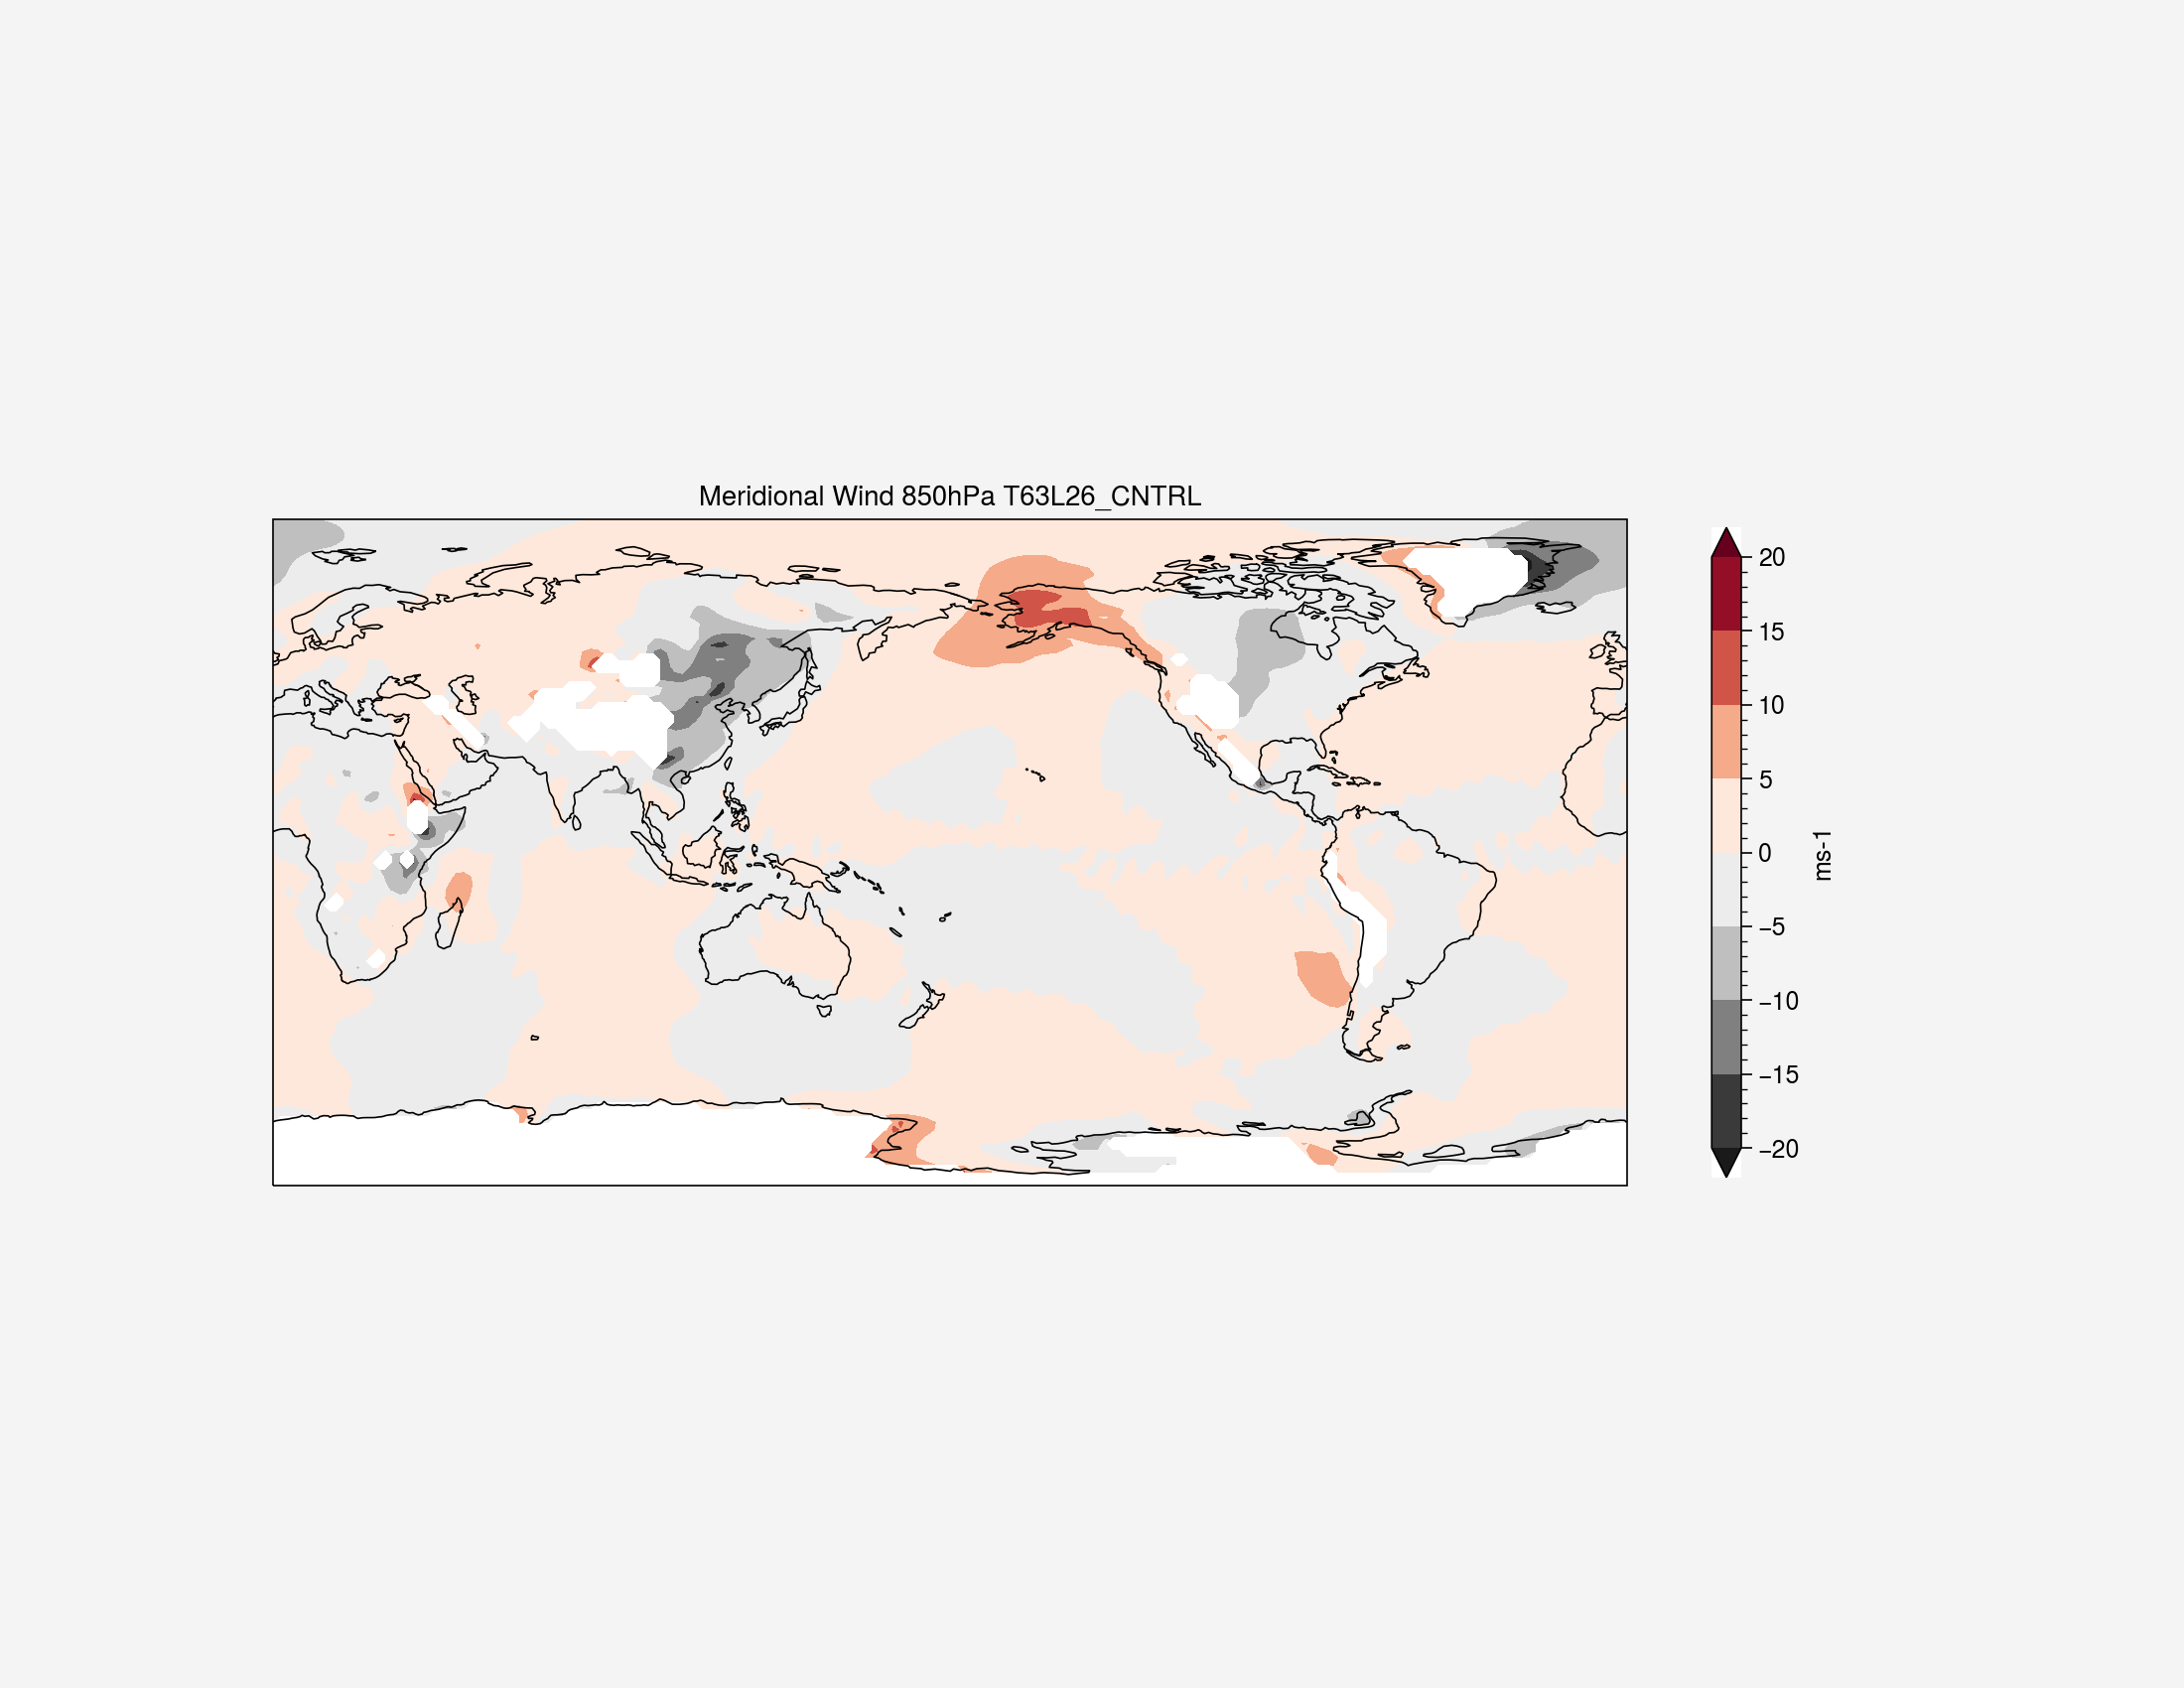

In [7]:
vname='v'
plev=850
clevs=np.arange(-20,21,5)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=ds_exps[vname].sel(lev=plev,exp=exp).mean(dim='time')
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both',levels=clevs)
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa '+exp)
plt.colorbar(cs,shrink=0.5,label='ms-1')

vname='v'
plev=850
exp='T63L26_HeatingALL10'

clevs=np.arange(-20,21,5)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
#data=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingAll')[0:59,:,:].mean(dim='time')
data=ds_exps[vname].sel(lev=plev,exp=exp).mean(dim='time')
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both',levels=clevs,
               title='Meridional Wind 850hPa')
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa '+exp)
plt.colorbar(cs,shrink=0.5,label='ms-1')

vname='v'
plev=850

clevs=np.arange(-20,21,5)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingSA')[0:60].mean(dim='time')
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both',levels=clevs,
               title='Meridional Wind 850hPa')
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingSA')
plt.colorbar(cs,shrink=0.5,label='ms-1')

vname='v'
plev=850

clevs=np.arange(-20,21,5)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingIOPAC')[0:60].mean(dim='time')
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both',levels=clevs,
               title='Meridional Wind 850hPa')
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingIOPAC')
plt.colorbar(cs,shrink=0.5,label='ms-1')

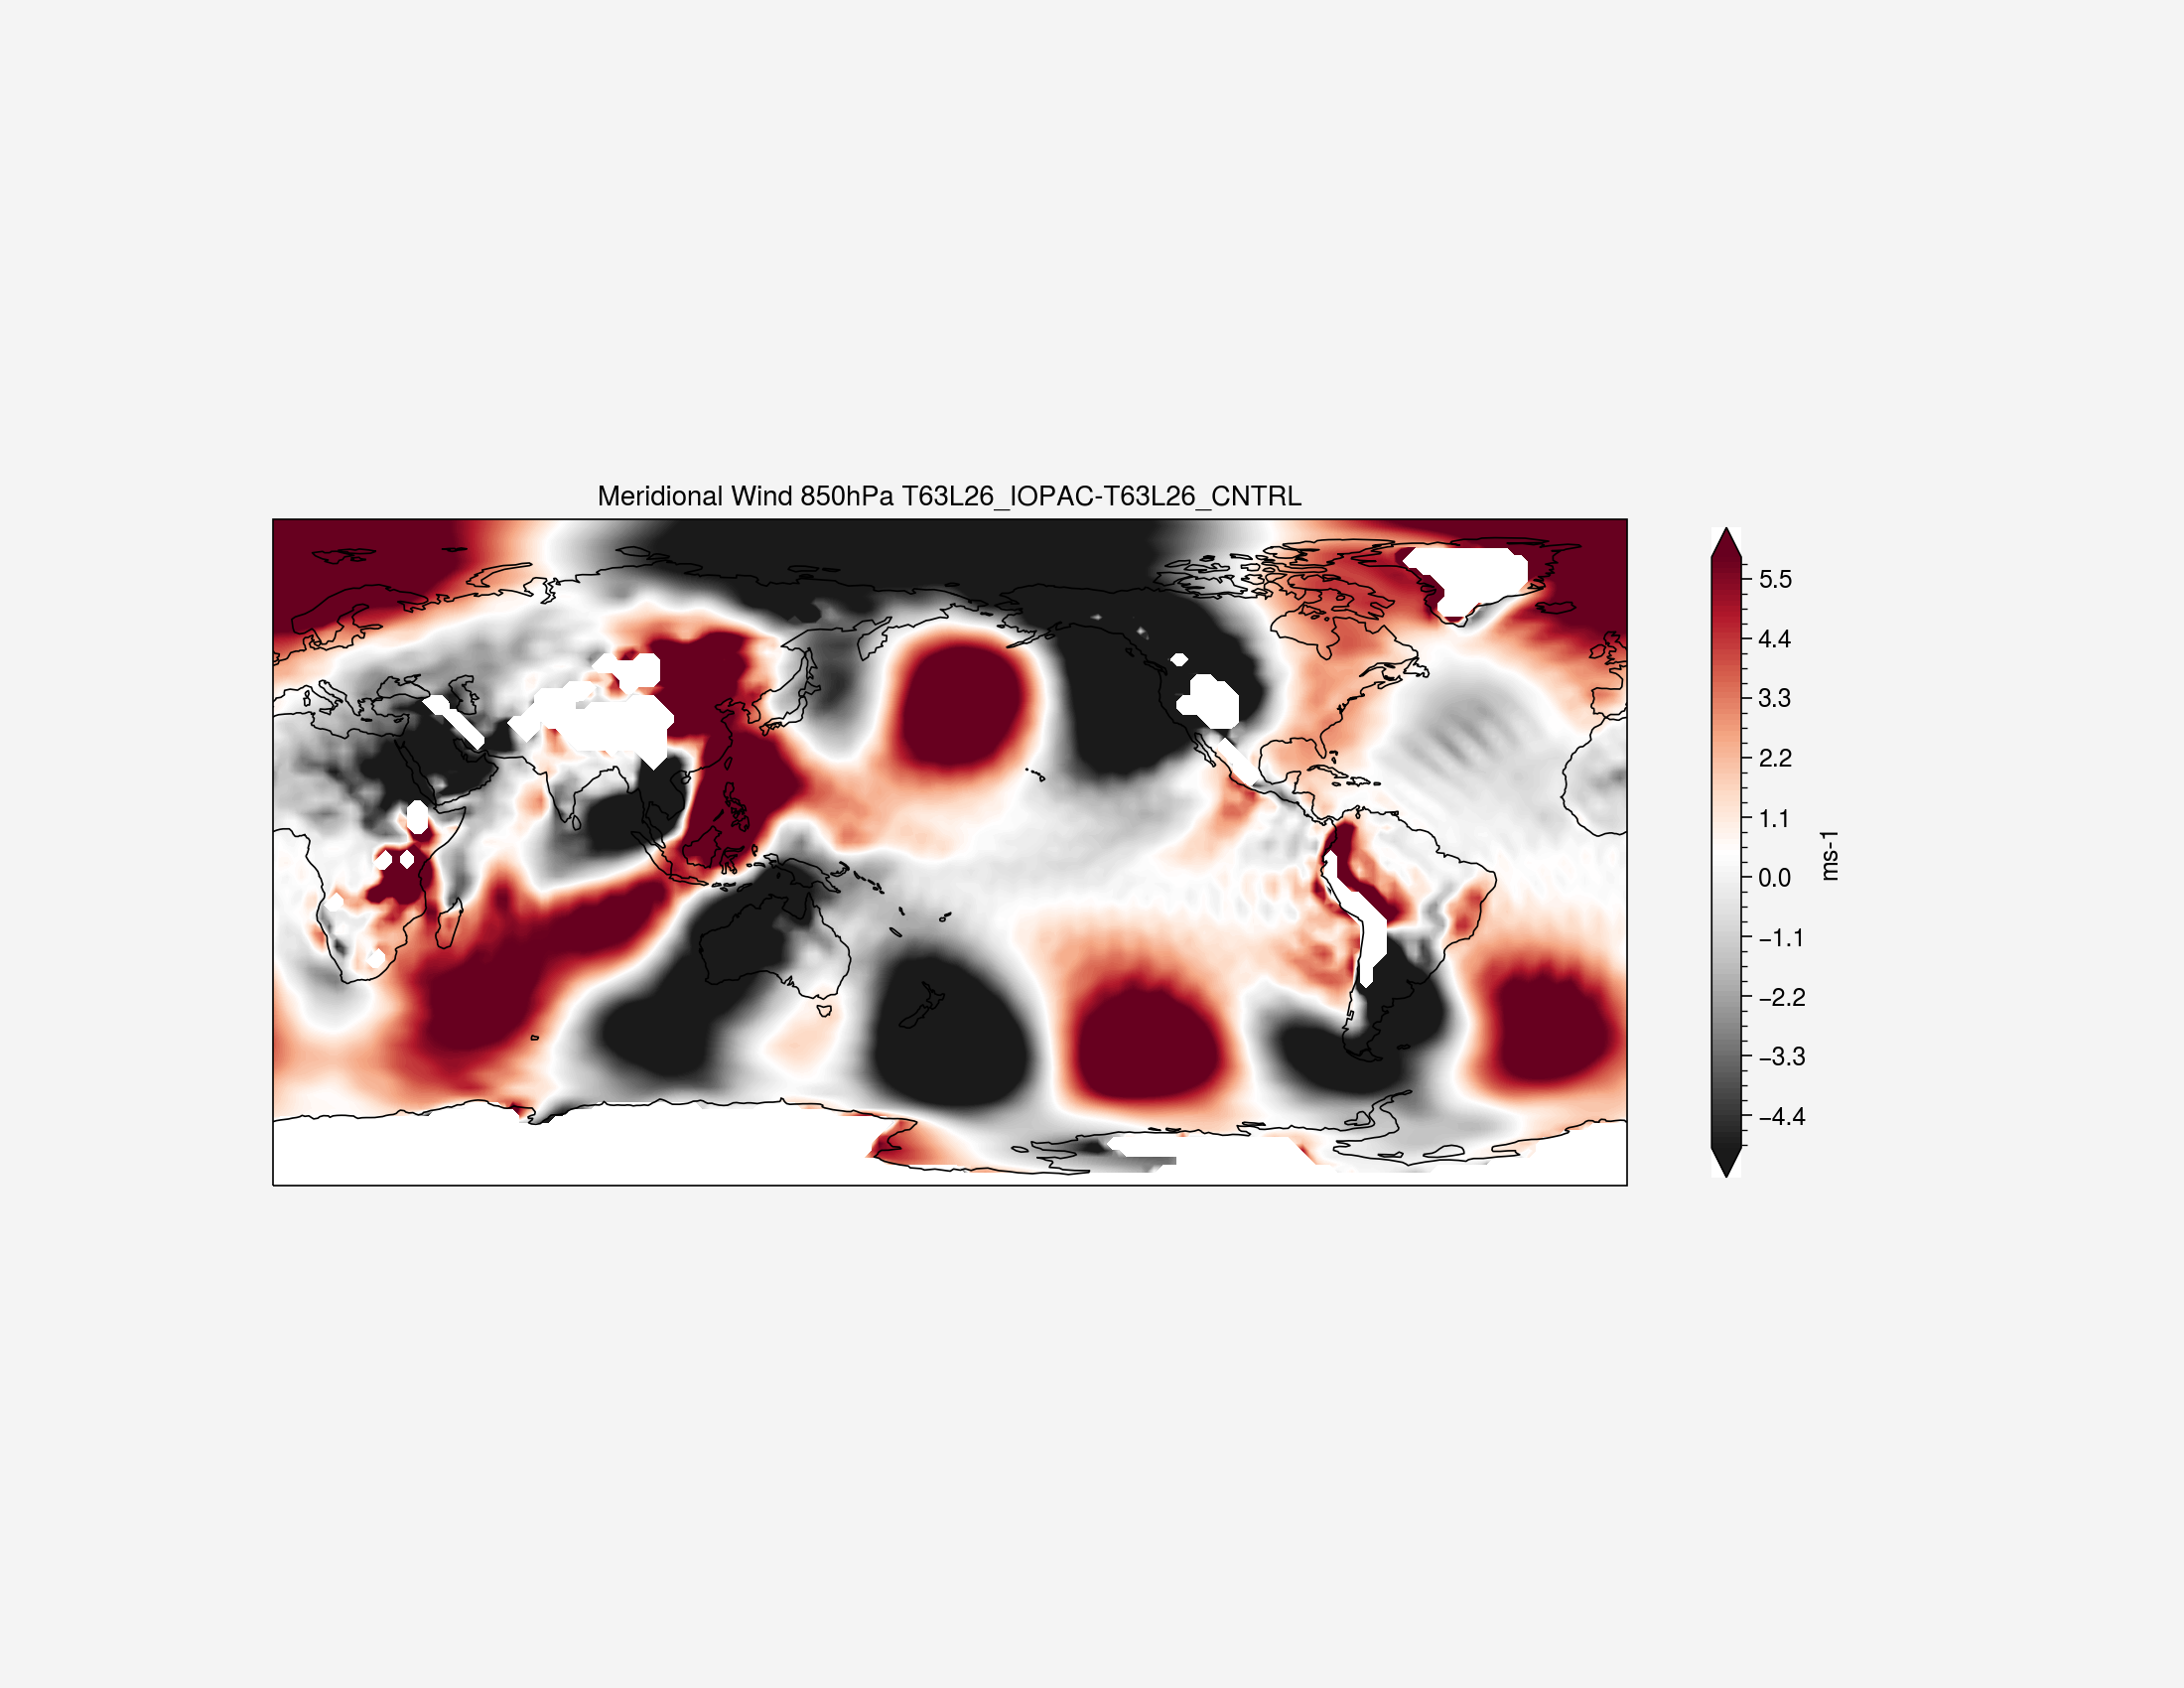

In [8]:
vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_CNTRL').mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_IOPAC').mean(dim='time')
diff=(exp_heating-exp_cntrl) 

clevs=np.arange(-10,11,2)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both', levels=np.arange(-5,6,0.1)) #levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_IOPAC-T63L26_CNTRL')
plt.colorbar(cs,shrink=0.5,label='ms-1')

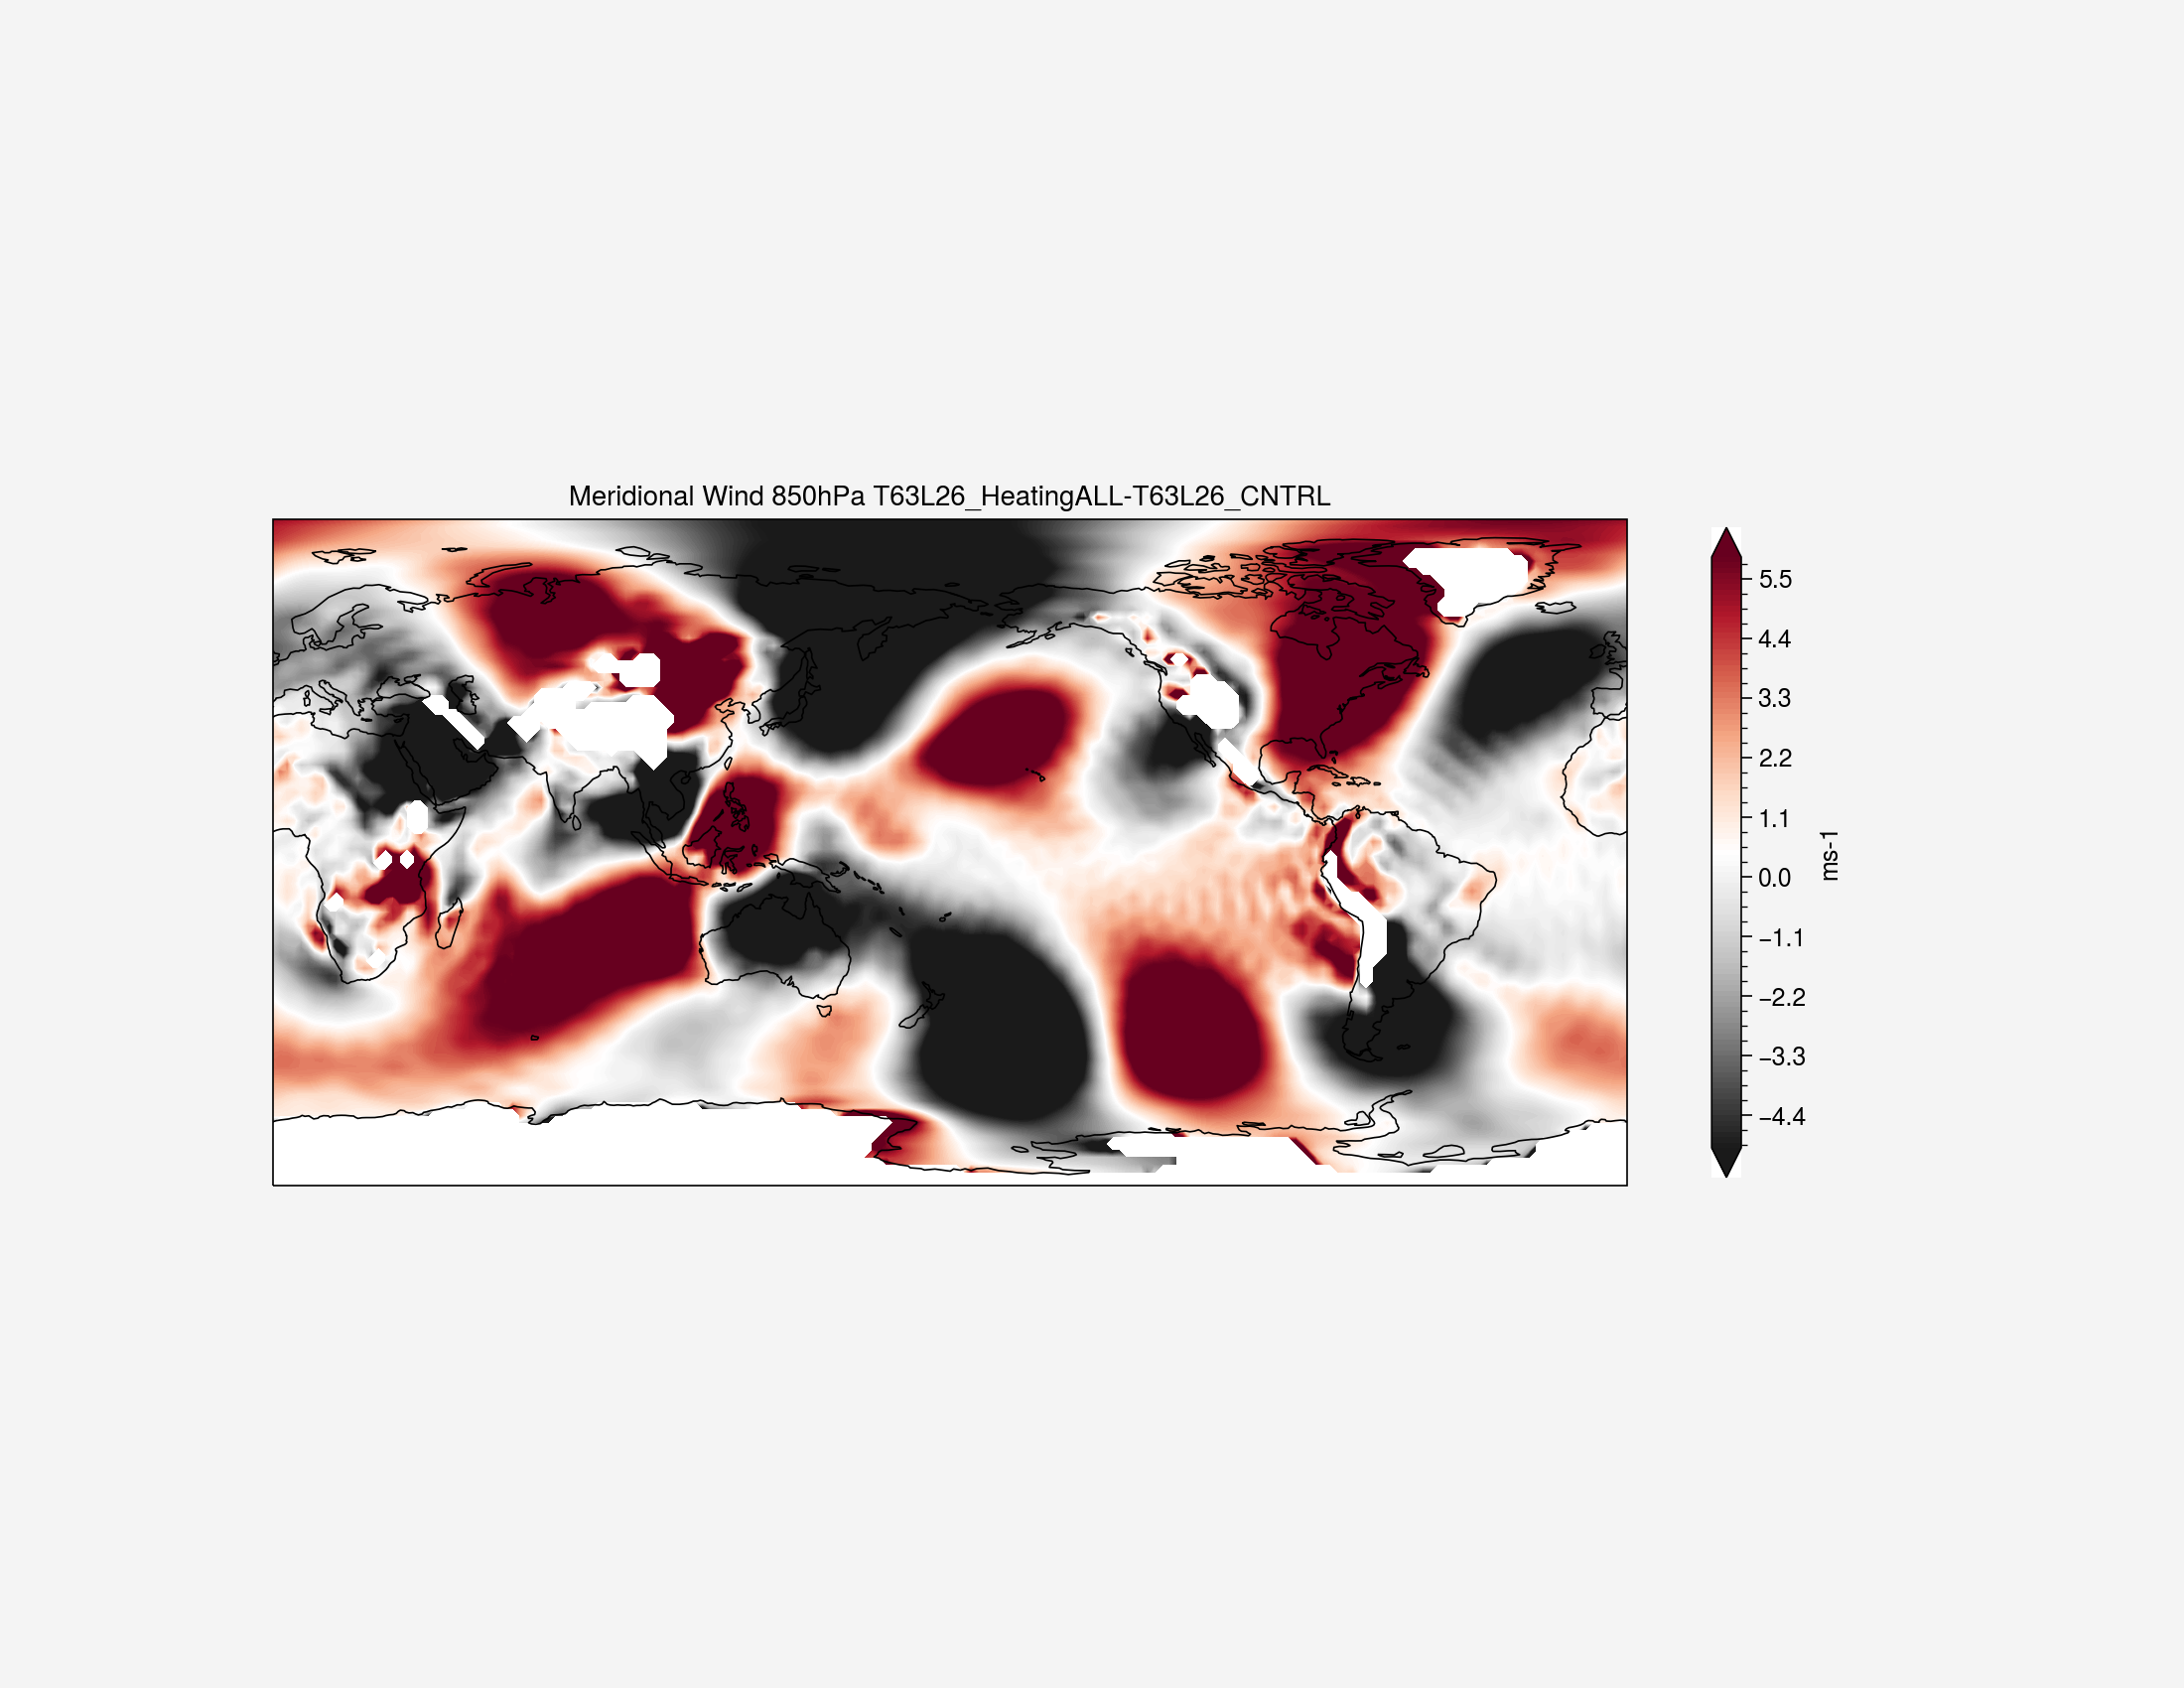

In [9]:
vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_CNTRL').mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingALL').mean(dim='time')
diff=(exp_heating-exp_cntrl) 

clevs=np.arange(-10,11,2)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both', levels=np.arange(-5,6,0.1)) #levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingALL-T63L26_CNTRL')
plt.colorbar(cs,shrink=0.5,label='ms-1')

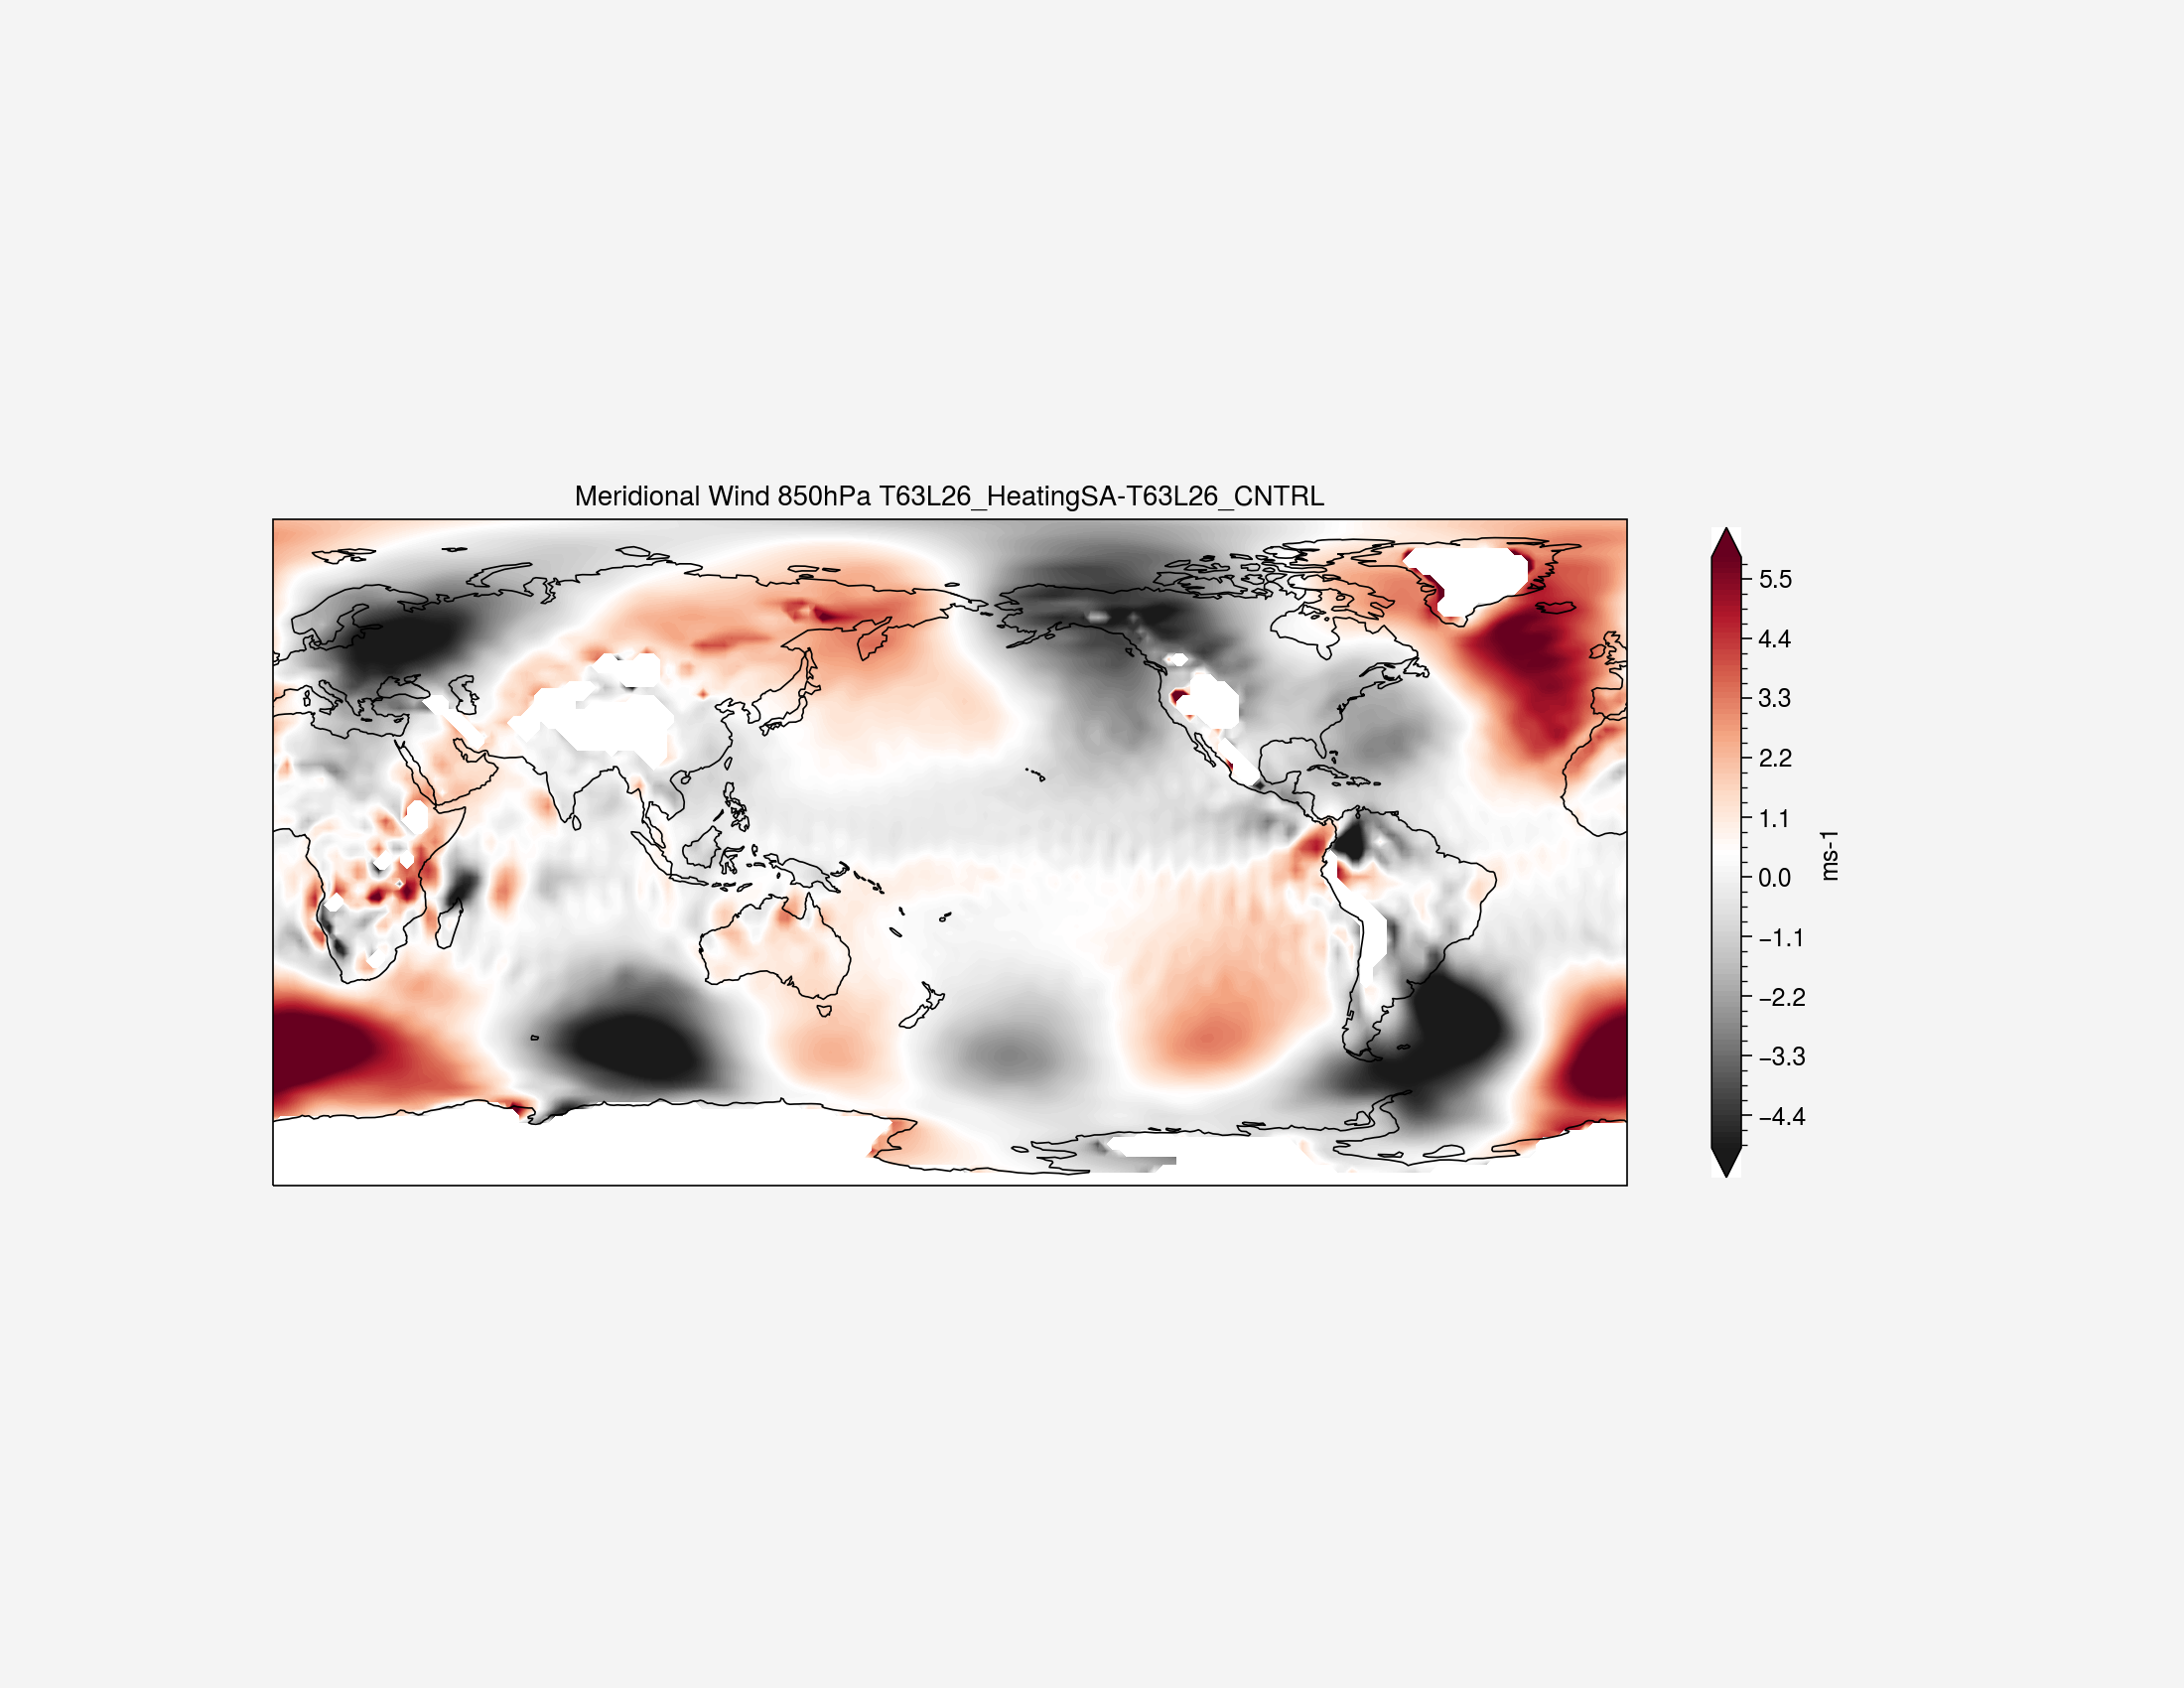

In [10]:
vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_CNTRL').mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingSA').mean(dim='time')
diff=(exp_heating-exp_cntrl) 

clevs=np.arange(-10,11,2)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both', levels=np.arange(-5,6,0.1)) #levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingSA-T63L26_CNTRL')
plt.colorbar(cs,shrink=0.5,label='ms-1')

In [11]:
vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingALL').mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingIOPAC').mean(dim='time')
diff=(exp_heating-exp_cntrl) 

clevs=np.arange(-10,11,2)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both', levels=np.arange(-5,6,0.1)) #levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingALL-T63L26_HeatingIOPAC')
plt.colorbar(cs,shrink=0.5,label='ms-1')

KeyError: "not all values found in index 'exp'. Try setting the `method` keyword argument (example: method='nearest')."

vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_CNTRL').mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingIOPAC100').mean(dim='time')
diff=(exp_heating-exp_cntrl) 

clevs=np.arange(-10,11,2)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both', levels=np.arange(-5,6,0.1)) #levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingIOPAC-T63L26_CNTRL')
plt.colorbar(cs,shrink=0.5,label='ms-1')

vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_CNTRL').mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingSA').mean(dim='time')
diff=(exp_heating-exp_cntrl) 

clevs=np.arange(-10,11,2)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both', levels=np.arange(-20,21,1)) #levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingSA-T63L26_CNTRL')
plt.colorbar(cs,shrink=0.5,label='ms-1')

vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_DJF').mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingIOPAC').mean(dim='time')
diff=(exp_heating-exp_cntrl) #.sum(dim='time')

clevs=np.arange(-20,21,5)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both',levels=np.arange(-5,6,0.1)) #,levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingIOPAC-T63L26_DJF')
plt.colorbar(cs,shrink=0.5,label='ms-1')

vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_DJF').mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingSA').mean(dim='time')
diff=(exp_heating-exp_cntrl) #.sum(dim='time')

clevs=np.arange(-20,21,5)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both',levels=np.arange(-5,6,0.1)) #,levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingSA-T63L26_DJF')
plt.colorbar(cs,shrink=0.5,label='ms-1')

vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingIOPAC') #.mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingAll') #.mean(dim='time')
diff=(exp_heating-exp_cntrl).sum(dim='time')

clevs=np.arange(-20,21,5)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both',levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingIOPAC-T63L26_HeatingAll')
plt.colorbar(cs,shrink=0.5,label='ms-1')

vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingSA') #.mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingAll') #.mean(dim='time')
diff=(exp_heating-exp_cntrl).sum(dim='time')

clevs=np.arange(-20,21,5)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both',levels=np.arange(-10,21,2)) #levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingSA-T63L26_HeatingAll')
plt.colorbar(cs,shrink=0.5,label='ms-1')

vname='v'
plev=850

exp_cntrl=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingSA').mean(dim='time')
exp_heating=ds_exps[vname].sel(lev=plev,exp='T63L26_HeatingIOPAC').mean(dim='time')
diff=(exp_heating-exp_cntrl) #.sum(dim='time')

clevs=np.arange(-20,21,5)
fig = plt.figure(figsize=(11.0,8.5))
ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
data=diff
data, lons = add_cyclic_point(data, coord=ds_exps['lon'])
cs=ax.contourf(lons, ds_exps['lat'],data,transform = ccrs.PlateCarree(),
               cmap='RdGy_r',extend='both',levels=np.arange(-1,2,0.2)) #,levels=np.arange(-250,260,25))
ax.coastlines()
plt.title('Meridional Wind '+str(plev)+'hPa T63L26_HeatingSA-T63L26_HeatingIOPAC')
plt.colorbar(cs,shrink=0.5,label='ms-1')